In [1]:
# Melbourne Housing Market - Decision Trees and Random Forests
# Jupyter Notebook Code

# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("Melbourne Housing Market.csv")

# Show basic info
print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

First 5 rows:


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0



Dataset shape: (13580, 21)

Columns:
['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']

Missing values:


BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
Car               62
Suburb             0
Bathroom           0
Regionname         0
Longtitude         0
Lattitude          0
Landsize           0
Bedroom2           0
Address            0
Postcode           0
Distance           0
Date               0
SellerG            0
Method             0
Price              0
Type               0
Rooms              0
dtype: int64

In [2]:
# =========================
# 3. Data Cleaning
# =========================

# Drop rows where target variable 'Price' is missing
df = df.dropna(subset=["Price"]).copy()

# Optional: remove columns that are usually not useful or too identifier-like
# You can adjust these depending on your dataset version
columns_to_drop = ["Address", "SellerG", "Date"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors="ignore")

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (13580, 18)


,Suburb,Rooms,Type,Price,Method,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,2,h,1480000.0,S,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1035000.0,S,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,3,h,1465000.0,SP,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,3,h,850000.0,PI,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,4,h,1600000.0,VB,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [4]:
# =========================
# 4. Define Features and Target
# =========================
X = df.drop("Price", axis=1)
y = df["Price"]

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
Categorical features: ['Suburb', 'Type', 'Method', 'CouncilArea', 'Regionname']


In [5]:
# =========================
# 5. Preprocessing
# =========================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [6]:
# =========================
# 6. Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (10864, 17)
Test set: (2716, 17)


In [7]:
# =========================
# 7. Decision Tree Model
# =========================
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=42))
])

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_preds)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_preds))
dt_r2 = r2_score(y_test, dt_preds)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)

Decision Tree Results
MAE : 214126.99762671717
RMSE: 346791.47914744256
R2  : 0.6972302733576714


In [8]:
# =========================
# 8. Random Forest Model
# =========================
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
MAE : 164800.4928952022
RMSE: 271244.02035993285
R2  : 0.8147765546673144


In [9]:
# =========================
# 9. Compare Models
# =========================
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "MAE": [dt_mae, rf_mae],
    "RMSE": [dt_rmse, rf_rmse],
    "R2 Score": [dt_r2, rf_r2]
})

display(results)

,Model,MAE,RMSE,R2 Score
0,Decision Tree,214126.997627,346791.479147,0.697230
1,Random Forest,164800.492895,271244.020360,0.814777


In [10]:
# =========================
# 10. Feature Importance for Random Forest
# =========================

# Get fitted preprocessor and model
fitted_preprocessor = rf_model.named_steps["preprocessor"]
fitted_rf = rf_model.named_steps["model"]

# Get one-hot encoded feature names
encoded_cat_names = fitted_preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_names)

# Feature importances
importances = fitted_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(feature_importance_df.head(15))

,Feature,Importance
364,Regionname_Southern Metropolitan,0.213511
0,Rooms,0.173569
1,Distance,0.138282
320,Type_u,0.087746
6,Landsize,0.082313
10,Longtitude,0.050682
7,BuildingArea,0.045685
9,Lattitude,0.037154
4,Bathroom,0.030259
8,YearBuilt,0.022002


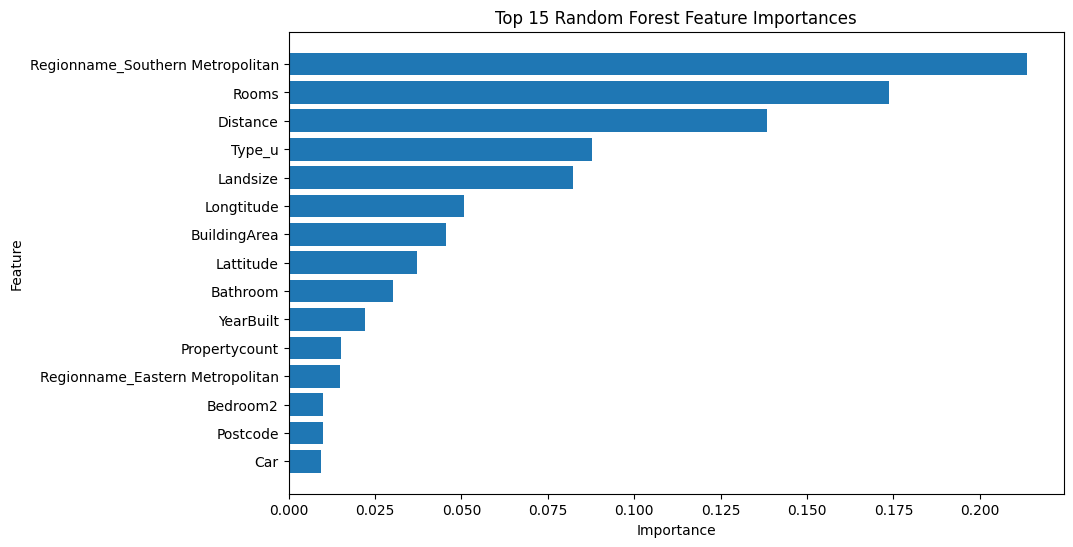

In [11]:
# =========================
# 11. Plot Top 15 Feature Importances
# =========================
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

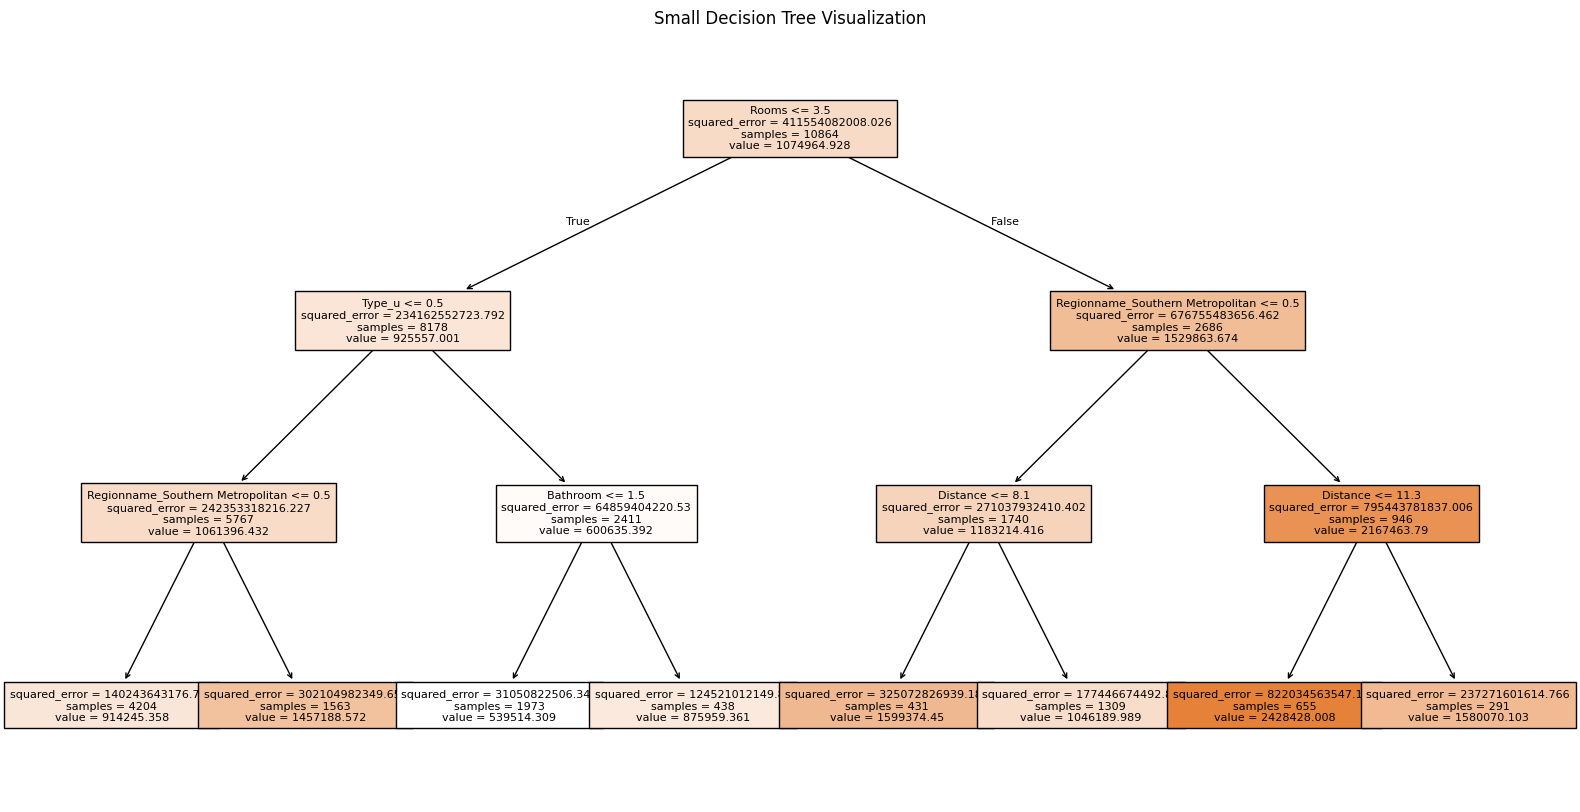

In [12]:
# =========================
# 12. Optional: Visualize a Small Decision Tree
# =========================
# To make a readable tree, fit a smaller model on preprocessed data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

small_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
small_tree.fit(X_train_processed, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    small_tree,
    filled=True,
    fontsize=8,
    feature_names=all_feature_names,
    max_depth=3
)
plt.title("Small Decision Tree Visualization")
plt.show()

In [13]:
# =========================
# 13. Make Predictions on New Data
# =========================
# Example: predicting first 5 rows from test set

sample_predictions = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Decision Tree Predicted": dt_preds[:5],
    "Random Forest Predicted": rf_preds[:5]
})

display(sample_predictions)

,Actual Price,Decision Tree Predicted,Random Forest Predicted
0,2600000.0,1.706692e+06,2.192717e+06
1,620000.0,5.041250e+05,6.465396e+05
2,1000000.0,1.635000e+06,1.020295e+06
3,430000.0,5.260690e+05,5.677574e+05
4,392250.0,9.498951e+05,9.429279e+05
